# Capstone Project 2: Predicting Third-Semester Retention
## Letters & Humanities versus Business Administration

## Objective

This notebook follows the **UPAD cycle** : **Understand, Prepare, Analyze, Deploy** ; to build classification models that predict whether a student will be retained in the third semester.

You will compare four models:

1. **Logistic Regression** using academic and demographic data  
2. **Decision Tree** using academic and demographic data  
3. **XGBoost** using academic and demographic data  
4. **XGBoost + Survey Data** using academic, demographic, and survey-text features

The analysis will also compare model performance for students in **Letters & Humanities** and **Business Administration**, followed by a short unsupervised learning extension.

# Understand

A university wants to identify students who may not continue into their third semester and determine whether prediction quality is consistent across academic colleges.

The main stakeholder question is:

> Which model provides the strongest third-semester retention predictions, and how consistently does it perform for students in Letters & Humanities and Business Administration?

## Capstone Tasks

You will:

1. Load regular and survey-enhanced datasets.
2. Create a binary third-semester retention target.
3. Prepare regular and survey-enhanced feature sets.
4. Train Logistic Regression, Decision Tree, XGBoost, and XGBoost with Survey Data.
5. Compare overall model performance.
6. Evaluate each model for Letters & Humanities and Business Administration.
7. Examine feature importance and the contribution of survey data.
8. Use PCA and K-Means to explore student survey profiles.
9. Recommend a model and summarize the findings.

# Prepare

## Data Wrangling

#### **Step 1: Import Libraries and Set the Data Path**

Import the libraries needed for data preparation, visualization, supervised learning, unsupervised learning, and model evaluation. The data path points to the Course 3 data folder in Google Drive.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)

DATA_DIR = Path('/content/drive/MyDrive/projects2/Applied-Data-Analytics-For-Higher-Education-Course-3/data')
print(f'Using data directory: {DATA_DIR}')

Using data directory: /content/drive/MyDrive/projects2/Applied-Data-Analytics-For-Higher-Education-Course-3/data


#### **Step 2: Load Regular and Survey-Enhanced Datasets**

Load the regular training and testing files for exploratory analysis and college labels. The survey master files contain machine-learning-ready academic, demographic, and survey-text features.

In [5]:
raw_train = pd.read_csv(DATA_DIR / 'training.csv')
raw_test = pd.read_csv(DATA_DIR / 'testing.csv')
survey_train = pd.read_csv(DATA_DIR / 'ML_SURVEY_MASTER_TRAIN.csv')
survey_test = pd.read_csv(DATA_DIR / 'ML_SURVEY_MASTER_TEST.csv')

print('Regular training shape:', raw_train.shape)
print('Regular testing shape:', raw_test.shape)
print('Survey training shape:', survey_train.shape)
print('Survey testing shape:', survey_test.shape)

display(raw_train.head())

Regular training shape: (19844, 27)
Regular testing shape: (5336, 27)
Survey training shape: (19844, 53)
Survey testing shape: (5336, 53)


,SID,COHORT,RACE_ETHNICITY,GENDER,FIRST_GEN_STATUS,HS_GPA,HS_MATH_GPA,HS_ENGL_GPA,COLLEGE,UNITS_ATTEMPTED_1,UNITS_ATTEMPTED_2,UNITS_ATTEMPTED_3,UNITS_COMPLETED_1,UNITS_COMPLETED_2,UNITS_COMPLETED_3,DFW_UNITS_1,DFW_UNITS_2,DFW_UNITS_3,GPA_1,GPA_2,GPA_3,SEM_3_STATUS,DFW_RATE_1,DFW_RATE_2,GRADE_POINTS_1,GRADE_POINTS_2,GRADE_POINTS_3
0,UHDOP5522,Fall 2020,Asian,Female,Continuing Generation,3.720,3.2,3.400,Visual & Performing Arts,15.0,14.0,15.0,15.0,15.0,16.0,0.0,0.0,0.0,4.000000,3.785714,4.0,E,0.0000,0.000000,60.0,53.0,60.0
1,UHE842CU6,Fall 2021,Black or African American,Female,Continuing Generation,3.189,2.6,3.750,Visual & Performing Arts,12.0,12.0,12.0,12.0,12.0,6.0,3.0,4.0,12.0,3.000000,2.500000,1.5,E,0.0000,0.000000,36.0,30.0,18.0
2,UHJFT1JAB,Fall 2018,Asian,Female,Continuing Generation,3.625,3.4,3.500,Visual & Performing Arts,15.0,15.0,15.0,15.0,16.0,16.0,0.0,0.0,0.0,3.800000,3.600000,3.6,E,0.0000,0.000000,57.0,54.0,54.0
3,UHKF05TAF,Fall 2018,Hispanic,Female,First Generation,3.606,3.0,3.375,Letters & Humanities,16.0,9.0,12.0,7.0,3.0,12.0,9.0,9.0,3.0,1.562500,1.000000,2.5,E,0.5625,0.666667,25.0,9.0,30.0
4,UHKKQ8UY5,Fall 2021,Hispanic,Male,Continuing Generation,3.536,2.5,2.625,Letters & Humanities,13.0,13.0,15.0,13.0,13.0,15.0,0.0,0.0,0.0,3.538462,3.769231,3.4,E,0.0000,0.000000,46.0,49.0,51.0


#### **Step 3: Create the Target Variable**

The original outcome column is `SEM_3_STATUS`. A value of `E` indicates that the student was enrolled in the third semester. Create a binary target where 1 represents retained and 0 represents not retained.

In [6]:
for df in [raw_train, raw_test, survey_train, survey_test]:
    df['RETAINED'] = (df['SEM_3_STATUS'] == 'E').astype(int)

target_summary = pd.DataFrame({
    'Training Count': survey_train['RETAINED'].value_counts().sort_index(),
    'Training Percent': survey_train['RETAINED'].value_counts(normalize=True).sort_index(),
    'Testing Count': survey_test['RETAINED'].value_counts().sort_index(),
    'Testing Percent': survey_test['RETAINED'].value_counts(normalize=True).sort_index()
})
target_summary.index = ['Not Retained (0)', 'Retained (1)']

display(target_summary.style.format({
    'Training Percent': '{:.2%}',
    'Testing Percent': '{:.2%}'
}))

,Training Count,Training Percent,Testing Count,Testing Percent
Not Retained (0),2637,13.29%,820,15.37%
Retained (1),17207,86.71%,4516,84.63%


#### **Step 4: Check Data Quality**

Review dataset size, duplicate rows, and missing values before modeling. This provides a concise overview of the condition of each file and identifies issues that may require preprocessing.

In [7]:
quality_summary = pd.DataFrame({
    'Dataset': ['raw_train', 'raw_test', 'survey_train', 'survey_test'],
    'Rows': [len(raw_train), len(raw_test), len(survey_train), len(survey_test)],
    'Columns': [raw_train.shape[1], raw_test.shape[1], survey_train.shape[1], survey_test.shape[1]],
    'Duplicate Rows': [
        raw_train.duplicated().sum(),
        raw_test.duplicated().sum(),
        survey_train.duplicated().sum(),
        survey_test.duplicated().sum()
    ],
    'Missing Values': [
        raw_train.isna().sum().sum(),
        raw_test.isna().sum().sum(),
        survey_train.isna().sum().sum(),
        survey_test.isna().sum().sum()
    ]
})

display(quality_summary)

,Dataset,Rows,Columns,Duplicate Rows,Missing Values
0,raw_train,19844,28,20,0
1,raw_test,5336,28,0,0
2,survey_train,19844,54,4,0
3,survey_test,5336,54,0,0


#### **Step 5: Define Regular and Survey Feature Sets**

Create one feature set without survey text components and one feature set that includes them. Comparing the two XGBoost models will show whether survey information adds predictive value.

In [8]:
TARGET_COL = 'RETAINED'
STATUS_COL = 'SEM_3_STATUS'

survey_text_features = [
    column for column in survey_train.columns
    if column.startswith('TEXT_PC')
]
survey_text_features = sorted(
    survey_text_features,
    key=lambda column: int(column.replace('TEXT_PC', ''))
)

base_features = [
    column for column in survey_train.columns
    if column not in [STATUS_COL, TARGET_COL] + survey_text_features
]
survey_features = base_features + survey_text_features

print('Base feature count:', len(base_features))
print('Survey text feature count:', len(survey_text_features))
print('Survey-enhanced feature count:', len(survey_features))

Base feature count: 19
Survey text feature count: 33
Survey-enhanced feature count: 52


#### **Step 6: Prepare Modeling Matrices**

Use the official training and testing files for all four models. Missing feature values are replaced with training-set medians so that the same preprocessing information is applied to the test data.

In [9]:
X_train_base = survey_train[base_features].apply(pd.to_numeric, errors='coerce')
X_test_base = survey_test[base_features].apply(pd.to_numeric, errors='coerce')
X_train_survey = survey_train[survey_features].apply(pd.to_numeric, errors='coerce')
X_test_survey = survey_test[survey_features].apply(pd.to_numeric, errors='coerce')

y_train = survey_train[TARGET_COL]
y_test = survey_test[TARGET_COL]

print('Base training matrix:', X_train_base.shape)
print('Survey-enhanced training matrix:', X_train_survey.shape)
print('Testing observations:', len(y_test))

Base training matrix: (19844, 19)
Survey-enhanced training matrix: (19844, 52)
Testing observations: 5336


#### **Step 7: Exploratory Data Analysis**

Examine subgroup sizes and observed retention rates for Letters & Humanities and Business Administration. These values provide context for interpreting later differences in model performance.

,Students,Retention_Rate
COLLEGE,,
Business Administration,2214,0.858
Letters & Humanities,2825,0.879


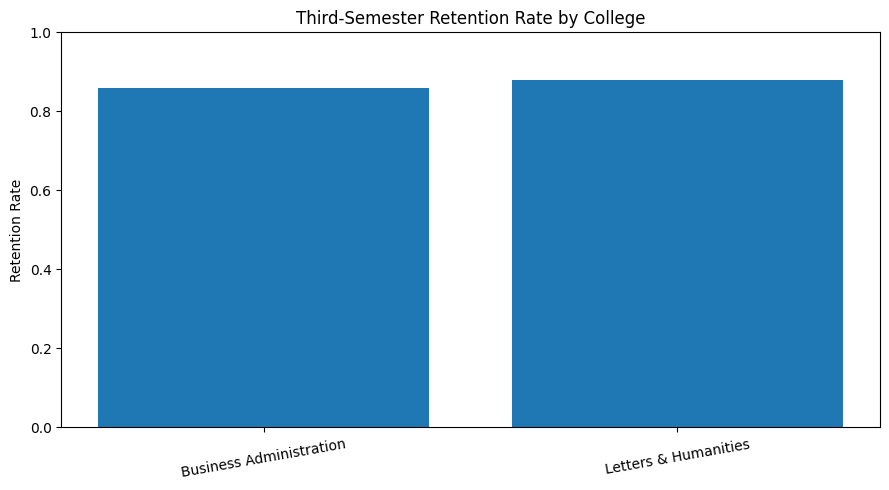

In [10]:
COLLEGES = ['Letters & Humanities', 'Business Administration']

college_summary = (
    raw_train[raw_train['COLLEGE'].isin(COLLEGES)]
    .groupby('COLLEGE')['RETAINED']
    .agg(Students='size', Retention_Rate='mean')
)
college_summary['Retention_Rate'] = college_summary['Retention_Rate'].round(3)
display(college_summary)

plt.figure(figsize=(9, 5))
plt.bar(college_summary.index, college_summary['Retention_Rate'])
plt.ylim(0, 1)
plt.ylabel('Retention Rate')
plt.title('Third-Semester Retention Rate by College')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

# Analyze

## Model Training and Evaluation

#### **Step 8: Build Logistic Regression Model**

Logistic Regression provides an interpretable baseline for the classification task. The pipeline fills missing values, standardizes the features, and balances the target classes during training.

In [11]:
logistic_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ))
])

logistic_model.fit(X_train_base, y_train)
print('Logistic Regression trained.')

Logistic Regression trained.


#### **Step 9: Build Decision Tree Model**

A Decision Tree can capture nonlinear relationships and interactions among student characteristics. Depth and leaf-size limits help control overfitting.

In [12]:
decision_tree_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', DecisionTreeClassifier(
        max_depth=7,
        min_samples_leaf=30,
        class_weight='balanced',
        random_state=42
    ))
])

decision_tree_model.fit(X_train_base, y_train)
print('Decision Tree trained.')

Decision Tree trained.


#### **Step 10: Build XGBoost Model Without Survey Data**

Train XGBoost using the same academic and demographic feature set used by the first two models. This creates a direct comparison among model families.

In [13]:
xgb_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', XGBClassifier(
        n_estimators=250,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train_base, y_train)
print('XGBoost trained without survey data.')

XGBoost trained without survey data.


#### **Step 11: Build XGBoost Model With Survey Data**

Train a second XGBoost model that adds the survey-text principal components. This model tests whether survey information improves third-semester retention prediction.

In [14]:
xgb_survey_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', XGBClassifier(
        n_estimators=250,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

xgb_survey_model.fit(X_train_survey, y_train)
print('XGBoost trained with survey data.')

XGBoost trained with survey data.


#### **Step 12: Review Model Training Summary**

Organize the trained models and their corresponding test matrices. This shared structure keeps the evaluation code consistent across all four models.

In [15]:
models = {
    'Logistic Regression': (logistic_model, X_test_base),
    'Decision Tree': (decision_tree_model, X_test_base),
    'XGBoost': (xgb_model, X_test_base),
    'XGBoost + Survey Data': (xgb_survey_model, X_test_survey)
}

model_summary = pd.DataFrame({
    'Model': models.keys(),
    'Feature Set': [
        'Academic + Demographic',
        'Academic + Demographic',
        'Academic + Demographic',
        'Academic + Demographic + Survey'
    ]
})

display(model_summary)

,Model,Feature Set
0,Logistic Regression,Academic + Demographic
1,Decision Tree,Academic + Demographic
2,XGBoost,Academic + Demographic
3,XGBoost + Survey Data,Academic + Demographic + Survey


#### **Step 13: Evaluate All Models**

Generate class predictions and retention probabilities, then compare accuracy, precision, recall, F1 score, and ROC-AUC on the same test set.

In [16]:
predictions = {}
probabilities = {}
results = []

for model_name, (model, X_test_model) in models.items():
    y_pred = model.predict(X_test_model)
    y_prob = model.predict_proba(X_test_model)[:, 1]

    predictions[model_name] = y_pred
    probabilities[model_name] = y_prob

    results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_test, y_prob)
    })

overall_results = pd.DataFrame(results).set_index('Model').sort_values('ROC_AUC', ascending=False)
display(overall_results.round(3))

,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
XGBoost,0.924,0.928,0.986,0.956,0.880
XGBoost + Survey Data,0.923,0.928,0.986,0.956,0.877
Decision Tree,0.893,0.947,0.926,0.936,0.863
Logistic Regression,0.831,0.941,0.853,0.895,0.837


#### **Step 14: Visualize Model Performance**

Display the main evaluation metrics together so that differences among the four models are easier to compare.

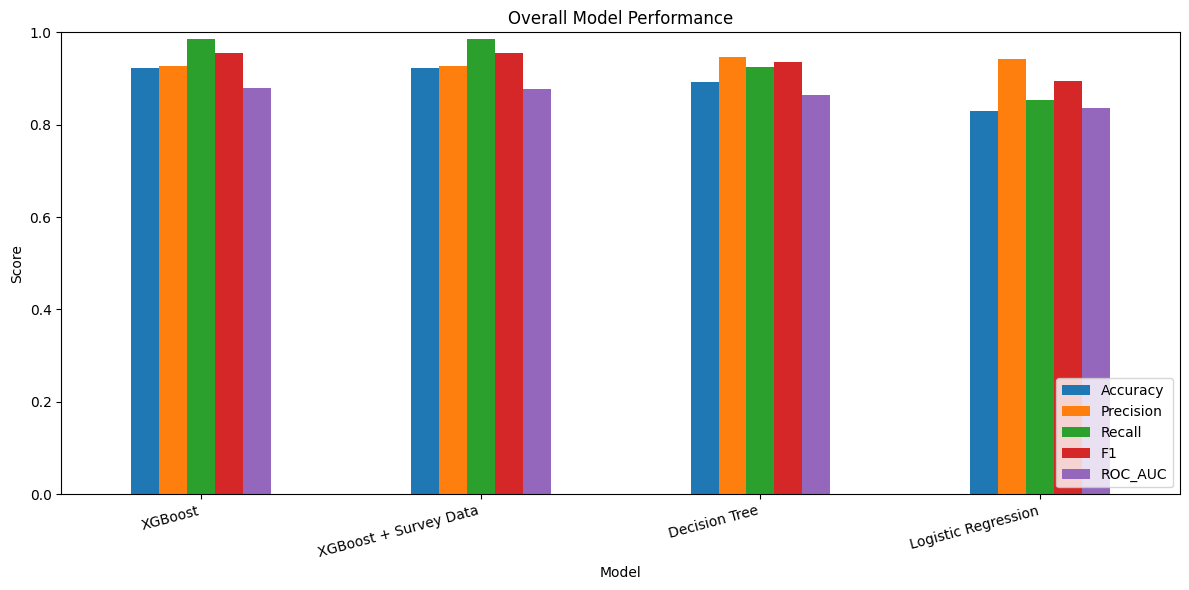

In [17]:
overall_results[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']].plot(
    kind='bar',
    figsize=(12, 6)
)
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Overall Model Performance')
plt.xticks(rotation=15, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

#### **Step 15: Compare ROC Curves**

ROC curves compare the true-positive and false-positive rates across classification thresholds. Curves closer to the upper-left corner indicate stronger ranking performance.

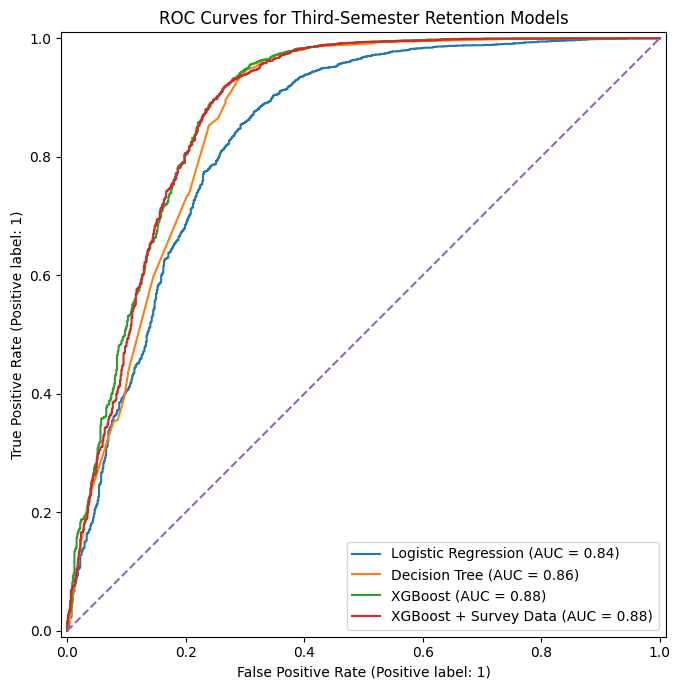

In [18]:
fig, ax = plt.subplots(figsize=(9, 7))

for model_name in models:
    RocCurveDisplay.from_predictions(
        y_test,
        probabilities[model_name],
        name=model_name,
        ax=ax
    )

ax.plot([0, 1], [0, 1], linestyle='--')
ax.set_title('ROC Curves for Third-Semester Retention Models')
plt.tight_layout()
plt.show()

#### **Step 16: Compare Confusion Matrices**

Confusion matrices show correct and incorrect predictions for retained and not-retained students. Review both error types because each can affect how an institution allocates outreach resources.

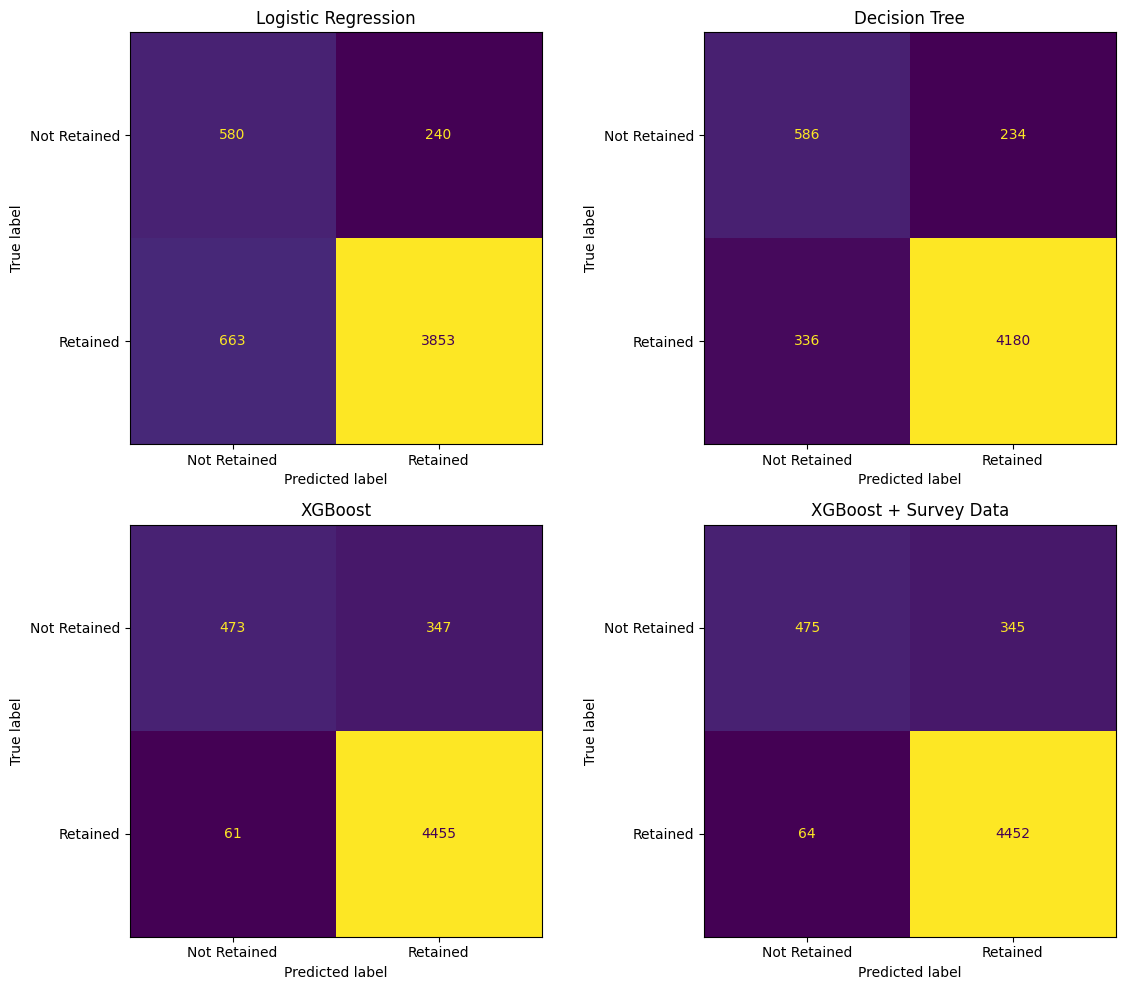

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, model_name in zip(axes.ravel(), models):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions[model_name],
        display_labels=['Not Retained', 'Retained'],
        colorbar=False,
        ax=ax
    )
    ax.set_title(model_name)

plt.tight_layout()
plt.show()

#### **Step 17: Compare Performance by College**

Evaluate every trained model separately for Letters & Humanities and Business Administration. The models remain trained on the full population, while the test results are divided by college for comparison.

,College,Model,Students,Accuracy,Precision,Recall,F1,ROC_AUC
0,Letters & Humanities,Logistic Regression,861,0.855,0.937,0.889,0.913,0.803
1,Letters & Humanities,Decision Tree,861,0.895,0.935,0.943,0.939,0.830
2,Letters & Humanities,XGBoost,861,0.914,0.920,0.985,0.951,0.851
3,Letters & Humanities,XGBoost + Survey Data,861,0.916,0.924,0.982,0.952,0.847
4,Business Administration,Logistic Regression,622,0.820,0.940,0.833,0.883,0.852
5,Business Administration,Decision Tree,622,0.915,0.960,0.935,0.947,0.903
6,Business Administration,XGBoost,622,0.923,0.931,0.978,0.954,0.900
7,Business Administration,XGBoost + Survey Data,622,0.923,0.928,0.982,0.954,0.901


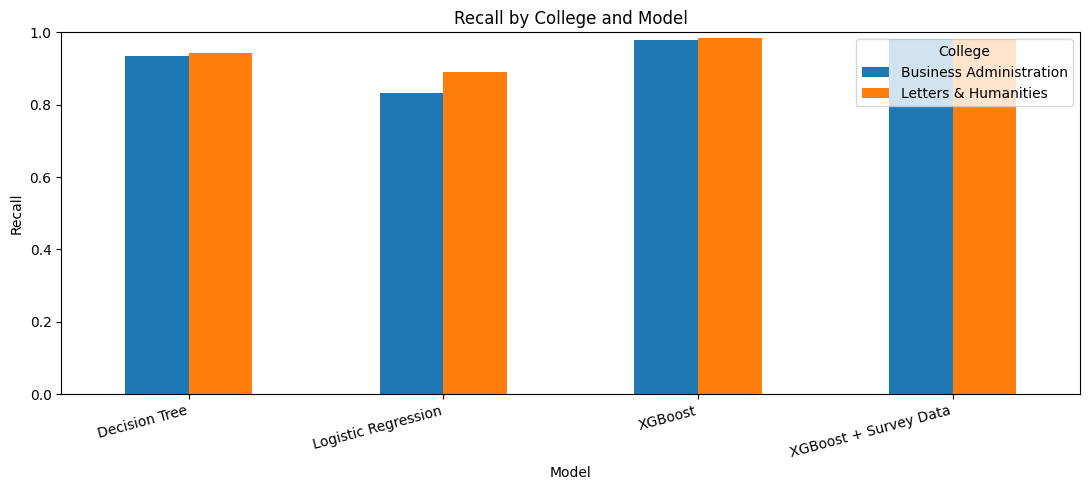

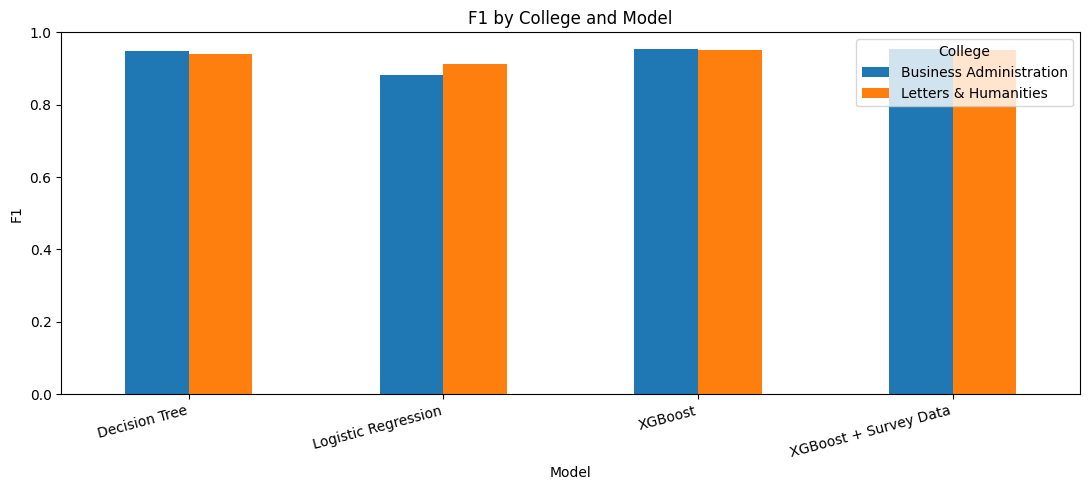

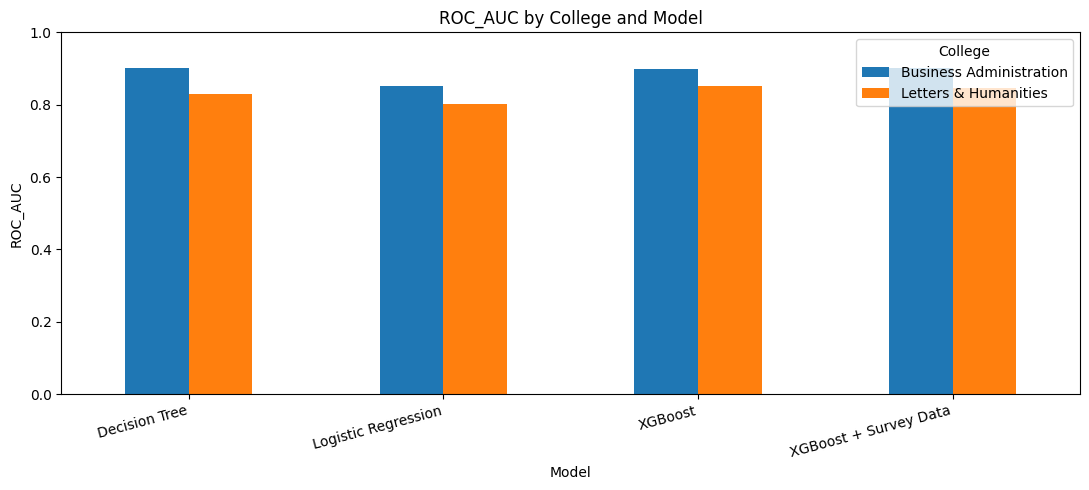

In [20]:
college_rows = []

for college in COLLEGES:
    mask = raw_test['COLLEGE'].eq(college).to_numpy()
    y_college = y_test.loc[mask]

    for model_name in models:
        college_rows.append({
            'College': college,
            'Model': model_name,
            'Students': int(mask.sum()),
            'Accuracy': accuracy_score(y_college, predictions[model_name][mask]),
            'Precision': precision_score(y_college, predictions[model_name][mask], zero_division=0),
            'Recall': recall_score(y_college, predictions[model_name][mask], zero_division=0),
            'F1': f1_score(y_college, predictions[model_name][mask], zero_division=0),
            'ROC_AUC': roc_auc_score(y_college, probabilities[model_name][mask])
        })

college_results = pd.DataFrame(college_rows)
display(college_results.round(3))

for metric in ['Recall', 'F1', 'ROC_AUC']:
    comparison = college_results.pivot(index='Model', columns='College', values=metric)
    comparison.plot(kind='bar', figsize=(11, 5))
    plt.ylim(0, 1)
    plt.ylabel(metric)
    plt.title(f'{metric} by College and Model')
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.show()

#### **Step 18: Compare Feature Importance**

Review the features that contribute most strongly to the two XGBoost models. Feature importance identifies predictive signals but does not establish that a feature causes retention or departure.

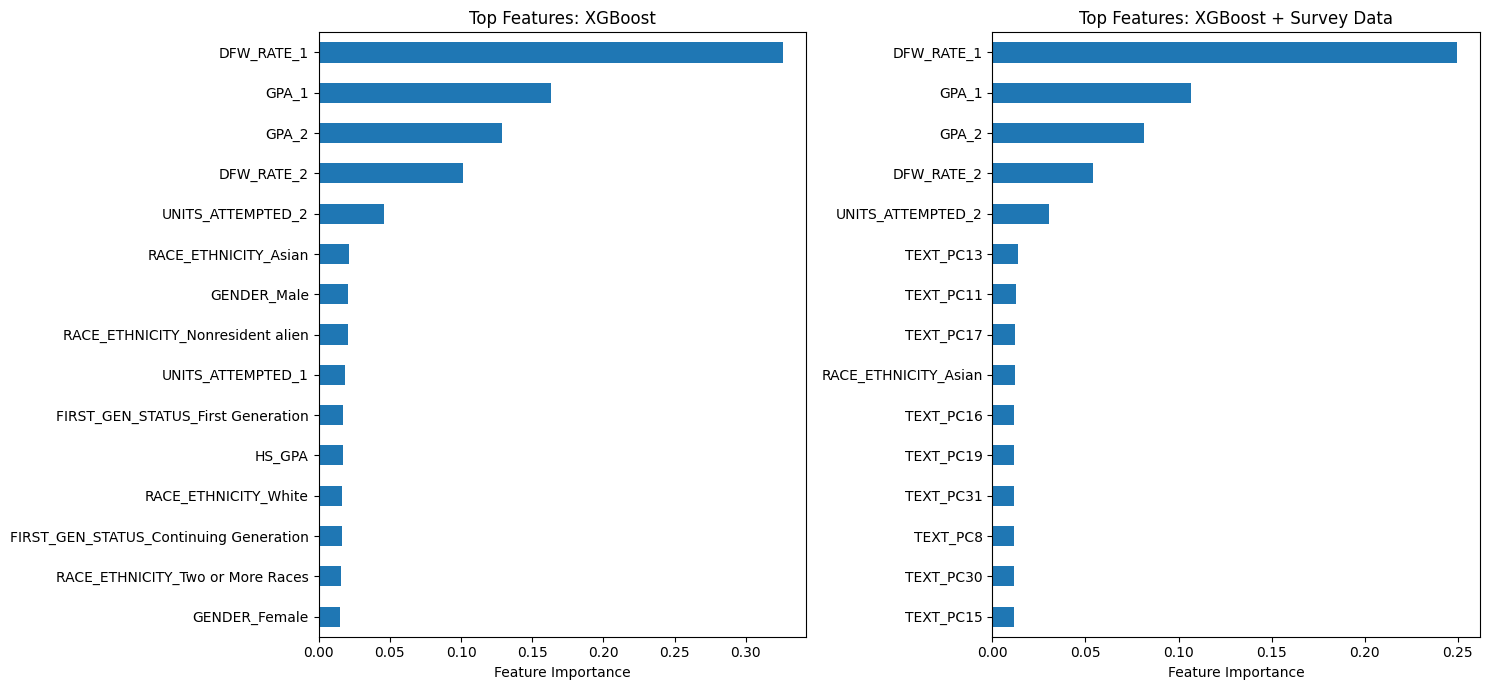

In [21]:
base_importance = pd.Series(
    xgb_model.named_steps['model'].feature_importances_,
    index=base_features
).sort_values(ascending=False).head(15)

survey_importance = pd.Series(
    xgb_survey_model.named_steps['model'].feature_importances_,
    index=survey_features
).sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
base_importance.sort_values().plot(kind='barh', ax=axes[0])
axes[0].set_title('Top Features: XGBoost')
axes[0].set_xlabel('Feature Importance')

survey_importance.sort_values().plot(kind='barh', ax=axes[1])
axes[1].set_title('Top Features: XGBoost + Survey Data')
axes[1].set_xlabel('Feature Importance')

plt.tight_layout()
plt.show()

#### **Step 19: Survey Data Impact Analysis**

Compare the two XGBoost models directly. Positive values indicate that the survey-enhanced model achieved a higher score than the XGBoost model without survey features.

In [22]:
survey_impact = (
    overall_results.loc['XGBoost + Survey Data'] -
    overall_results.loc['XGBoost']
).to_frame('Survey Model Difference')

display(survey_impact.round(3))

survey_college_comparison = college_results[
    college_results['Model'].isin(['XGBoost', 'XGBoost + Survey Data'])
].pivot(index='College', columns='Model', values=['Recall', 'F1', 'ROC_AUC'])

display(survey_college_comparison.round(3))

,Survey Model Difference
Accuracy,-0.000
Precision,0.000
Recall,-0.001
F1,-0.000
ROC_AUC,-0.003


Recall                            F1  \
Model                   XGBoost XGBoost + Survey Data XGBoost   
College                                                         
Business Administration   0.978                 0.982   0.954   
Letters & Humanities      0.985                 0.982   0.951   

                                              ROC_AUC                        
Model                   XGBoost + Survey Data XGBoost XGBoost + Survey Data  
College                                                                      
Business Administration                 0.954   0.900                 0.901  
Letters & Humanities                    0.952   0.851                 0.847

#### **Step 20: Unsupervised Learning Extension — Student Survey Profiles**

Supervised learning predicts a known outcome, while unsupervised learning searches for patterns without using the target. Use three K-Means clusters and PCA to explore broad student survey profiles.

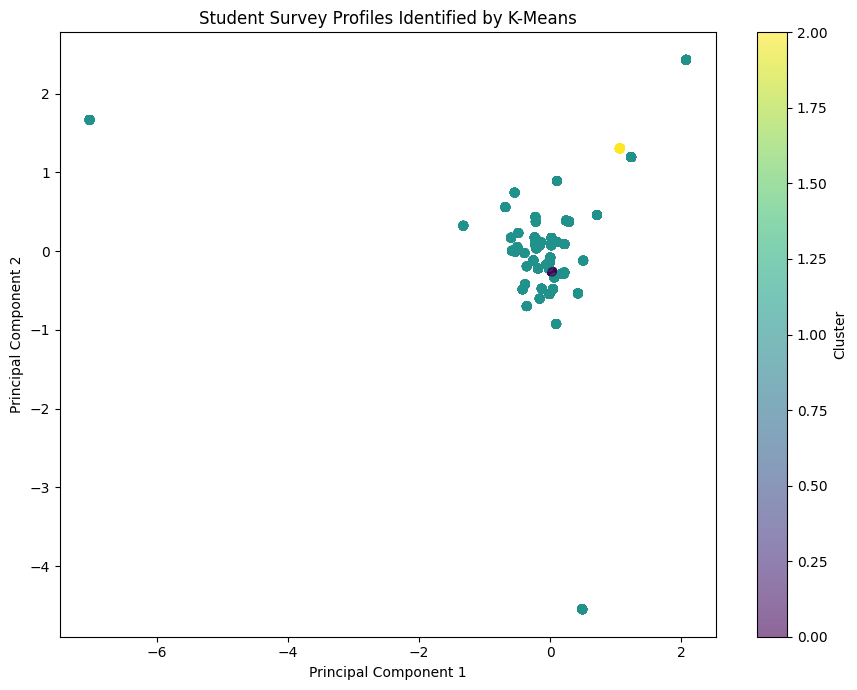

,Students,Retention_Rate
Cluster,,
0,129,0.922
1,3737,0.869
2,134,0.888


College Group,Business Administration,Letters & Humanities,Other Colleges
Cluster,,,
0,0.085,0.116,0.798
1,0.114,0.149,0.738
2,0.112,0.127,0.761


In [23]:
cluster_data = survey_train[survey_text_features].copy()
cluster_data = cluster_data.fillna(cluster_data.median())

sample_size = min(4000, len(cluster_data))
cluster_sample = cluster_data.sample(sample_size, random_state=42)

cluster_scaler = StandardScaler()
cluster_scaled = cluster_scaler.fit_transform(cluster_sample)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(cluster_scaled)

pca = PCA(n_components=2)
pca_coordinates = pca.fit_transform(cluster_scaled)

cluster_plot = pd.DataFrame({
    'PC1': pca_coordinates[:, 0],
    'PC2': pca_coordinates[:, 1],
    'Cluster': cluster_labels
}, index=cluster_sample.index)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    cluster_plot['PC1'],
    cluster_plot['PC2'],
    c=cluster_plot['Cluster'],
    alpha=0.6
)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Student Survey Profiles Identified by K-Means')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

cluster_profile = raw_train.loc[cluster_plot.index, ['COLLEGE', 'RETAINED']].copy()
cluster_profile['Cluster'] = cluster_labels
cluster_profile['College Group'] = np.where(
    cluster_profile['COLLEGE'].isin(COLLEGES),
    cluster_profile['COLLEGE'],
    'Other Colleges'
)

cluster_summary = cluster_profile.groupby('Cluster').agg(
    Students=('RETAINED', 'size'),
    Retention_Rate=('RETAINED', 'mean')
)
cluster_summary['Retention_Rate'] = cluster_summary['Retention_Rate'].round(3)

display(cluster_summary)
display(pd.crosstab(
    cluster_profile['Cluster'],
    cluster_profile['College Group'],
    normalize='index'
).round(3))

##### Reflection Questions: Unsupervised Learning

1. What differences do you observe among the three clusters?
2. Do the clusters have different observed retention rates?
3. How are Letters & Humanities and Business Administration represented across the clusters?
4. How could clustering complement a supervised retention model?
5. What cautions should an institution consider before using cluster membership in student-support decisions?

#### **Step 21: Model Selection — Determine the Recommended Model**

Select a model by considering overall predictive performance, college-level consistency, interpretability, and the contribution of survey information. The model with the highest ROC-AUC is displayed as a starting point for the final recommendation.

In [24]:
best_model_name = overall_results['ROC_AUC'].idxmax()

print('Model with the highest overall ROC-AUC:', best_model_name)
print()
print('Overall performance:')
display(overall_results.loc[[best_model_name]].round(3))

print()
print('College-level performance:')
display(
    college_results[college_results['Model'] == best_model_name]
    .set_index('College')
    .round(3)
)

Model with the highest overall ROC-AUC: XGBoost

Overall performance:


,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
XGBoost,0.924,0.928,0.986,0.956,0.88



College-level performance:


,Model,Students,Accuracy,Precision,Recall,F1,ROC_AUC
College,,,,,,,
Letters & Humanities,XGBoost,861,0.914,0.920,0.985,0.951,0.851
Business Administration,XGBoost,622,0.923,0.931,0.978,0.954,0.900


# Deploy

The final stage translates model results into clear recommendations for institutional stakeholders. The report should acknowledge limitations and emphasize that model predictions are intended to support—not replace—professional judgment.

#### **Step 22: Produce a Comprehensive Report on Your Findings**

Prepare a concise report using the sections below. Support each conclusion with evidence from the notebook outputs.

## 1. Problem and Data

Explain the third-semester retention outcome, the regular and survey-enhanced data, and the comparison between Letters & Humanities and Business Administration.

## 2. Overall Model Performance

Compare Logistic Regression, Decision Tree, XGBoost, and XGBoost with Survey Data.

Address the following questions:

- Which model performed best overall?
- Which metrics were most important for this retention problem?
- Did survey data improve model performance?

## 3. College-Level Performance

Summarize performance for Letters & Humanities and Business Administration.

Address the following questions:

- Did model performance differ between the colleges?
- Which model produced the most consistent results?
- What limitations should be considered when interpreting subgroup differences?

## 4. Model Interpretation

Discuss the most important predictors from the XGBoost models. Explain how feature importance can support further investigation without being interpreted as evidence of causation.

## 5. Unsupervised Learning Insights

Describe the three survey-profile clusters and their retention patterns. Explain how clustering could complement supervised prediction when planning student-support services.

## 6. Recommendation

Recommend one model for further institutional evaluation. Support the recommendation using overall performance, college-level consistency, interpretability, and the contribution of survey data.

Conclude with at least two practical recommendations for responsible use of the model.